In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("mumbai_property_coordinates_corrected_v2.csv")
df.head()

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,...,age,total_floors,latitude,longitude,new_latitude,new_longitude,new_pincode,coordinate_method,coordinate_confidence,pincode_method
0,Octave Parijas Horizon,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,...,0,1,19.244410,73.123253,19.244410,73.123253,421301,title_locality_median,Medium-High,locality_official_reference
1,Shakti Siyara Heights,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,...,0,1,19.257294,73.148872,19.257294,73.148872,421301,title_locality_median,Medium-High,locality_official_reference
2,Bhagwati Bhagwati Celeste,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,...,0,1,19.209026,73.081276,19.209026,73.087517,421201,title_locality_median,Medium-High,locality_official_reference
3,Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Ope...,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,...,0,1,19.097841,72.851158,19.100000,72.850000,400056,web_verified_locality,High,locality_reference
4,J P Ruchita Bliss,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,...,0,1,19.420601,72.809319,19.420601,72.809319,401209,title_locality_median,Medium-High,nearest_reference_locality


In [ ]:
df.shape

(71938, 21)

In [ ]:
initial_rows = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {initial_rows - len(df):,} exact duplicate rows. Remaining rows: {len(df):,}")

Removed 20,171 exact duplicate rows. Remaining rows: 51,767


In [ ]:
df.describe(include='all')

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,...,age,total_floors,latitude,longitude,new_latitude,new_longitude,new_pincode,coordinate_method,coordinate_confidence,pincode_method
count,51767,5.176700e+04,51767.000000,51767.000000,51767,51767,51767,51767.000000,51767.000000,51767.000000,...,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000,51767,51767,51767
unique,9277,NaN,NaN,NaN,408,4,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,4,3
top,,NaN,NaN,NaN,Thane,Mumbai,Apartment,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,title_locality_median,Medium-High,locality_official_reference
freq,9591,NaN,NaN,NaN,5292,50711,50960,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34366,34366,46876
mean,NaN,2.029837e+07,973.682018,18390.293804,NaN,NaN,NaN,2.000444,2.100836,0.164468,...,2.363919,1.003748,19.172944,72.966697,19.160265,72.954611,404101.908957,NaN,NaN,NaN
std,NaN,3.467431e+07,661.831575,13099.807453,NaN,NaN,NaN,0.929445,0.862753,0.592744,...,4.377339,0.323734,0.532951,0.457737,0.179025,0.276712,7101.100414,NaN,NaN,NaN
min,NaN,3.200000e+04,123.000000,25.376685,NaN,NaN,NaN,0.000000,1.000000,0.000000,...,0.000000,1.000000,12.889899,72.435379,18.749390,72.516220,400001.000000,NaN,NaN,NaN
25%,NaN,6.500000e+06,610.000000,8901.538576,NaN,NaN,NaN,1.000000,2.000000,0.000000,...,0.000000,1.000000,19.069774,72.856712,19.070822,72.856903,400067.000000,NaN,NaN,NaN
50%,NaN,1.200000e+07,804.000000,15642.000000,NaN,NaN,NaN,2.000000,2.000000,0.000000,...,0.000000,1.000000,19.160484,72.913185,19.160271,72.911873,400601.000000,NaN,NaN,NaN
75%,NaN,2.200000e+07,1144.000000,23855.656316,NaN,NaN,NaN,3.000000,2.000000,0.000000,...,3.000000,1.000000,19.228041,73.021202,19.228140,73.020584,401404.000000,NaN,NaN,NaN


In [ ]:
df.drop(columns=['balcony_num','latitude', 'longitude', 'coordinate_method', 'coordinate_confidence', 'pincode_method','age'], inplace=True)

post_drop_duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {post_drop_duplicates:,} duplicates after dropping unused columns.")

Removed 694 duplicates after dropping unused columns.


In [ ]:
df['city'] = df['city'].replace(['Western Mumbai','Central Mumbai','Mumbai South'],'Mumbai')
df['city'].value_counts()

city
Mumbai    51073
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51073 entries, 0 to 51072
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           51073 non-null  str    
 1   price           51073 non-null  int64  
 2   area            51073 non-null  int64  
 3   price_per_sqft  51073 non-null  float64
 4   locality        51073 non-null  str    
 5   city            51073 non-null  str    
 6   property_type   51073 non-null  str    
 7   bedroom_num     51073 non-null  int64  
 8   bathroom_num    51073 non-null  int64  
 9   furnished       51073 non-null  str    
 10  total_floors    51073 non-null  int64  
 11  new_latitude    51073 non-null  float64
 12  new_longitude   51073 non-null  float64
 13  new_pincode     51073 non-null  int64  
dtypes: float64(3), int64(6), str(5)
memory usage: 8.0 MB


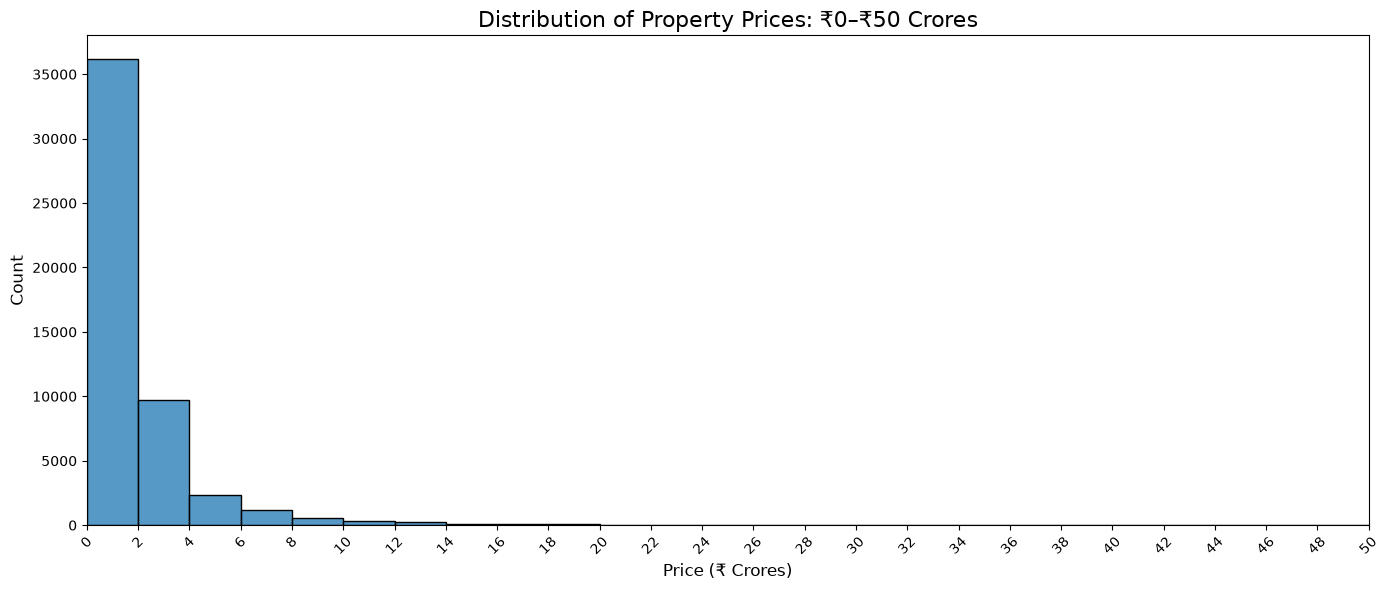

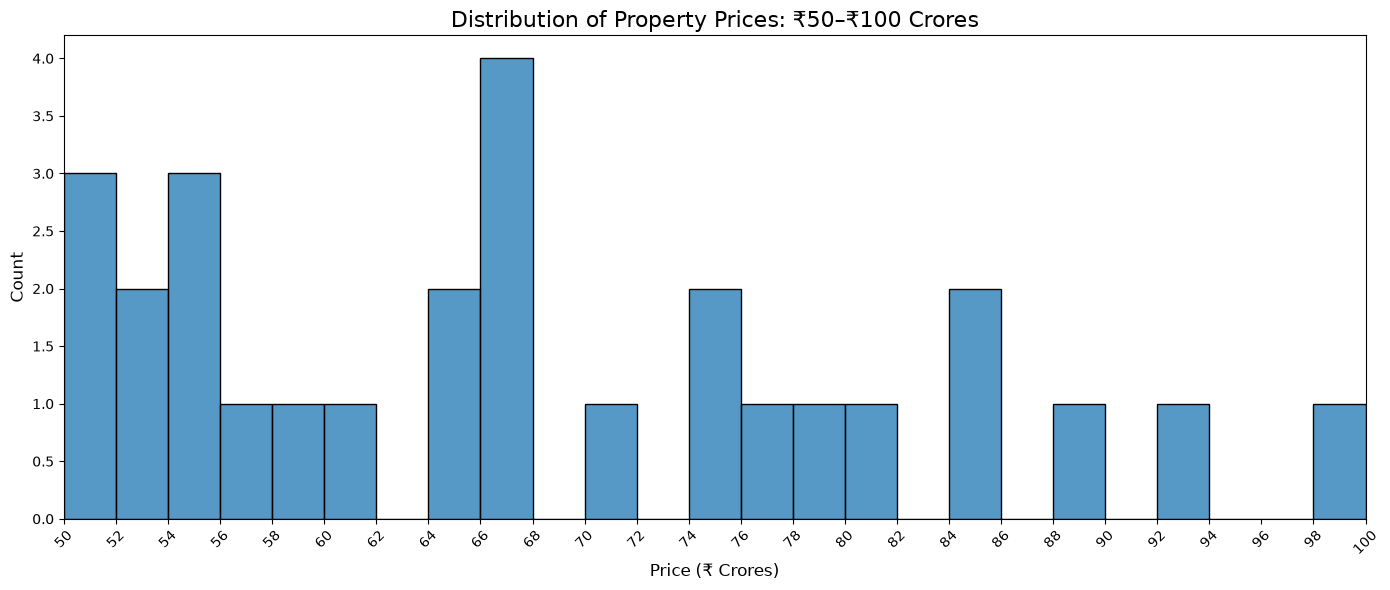

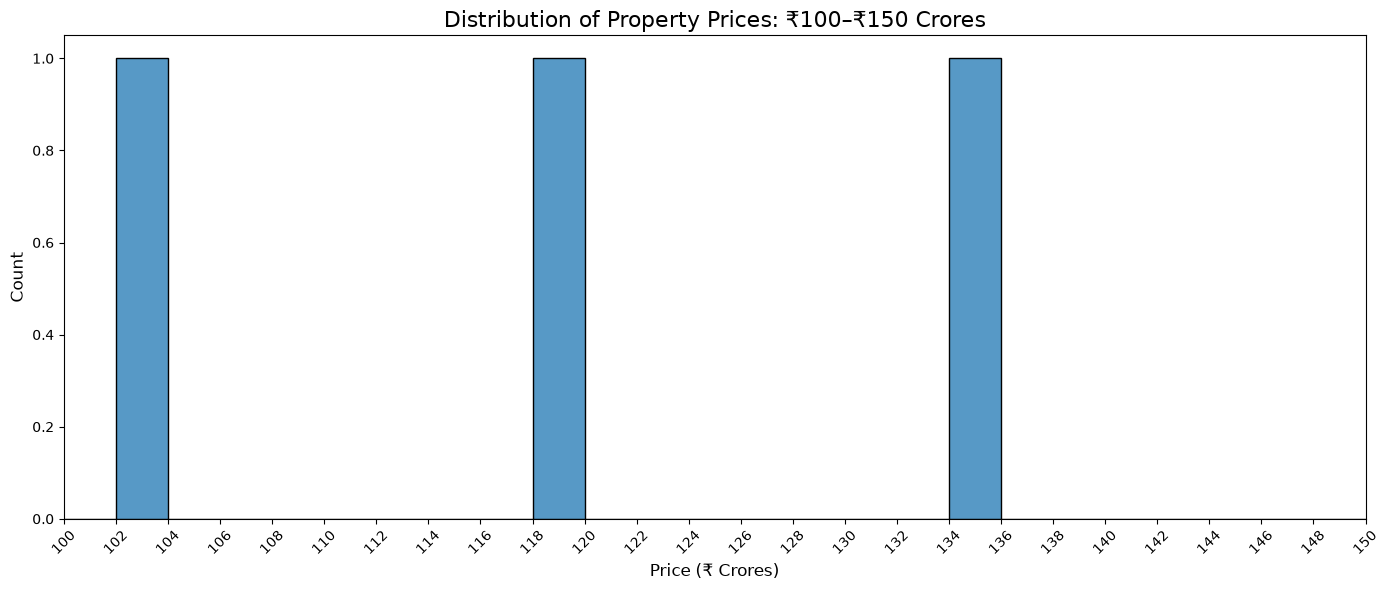

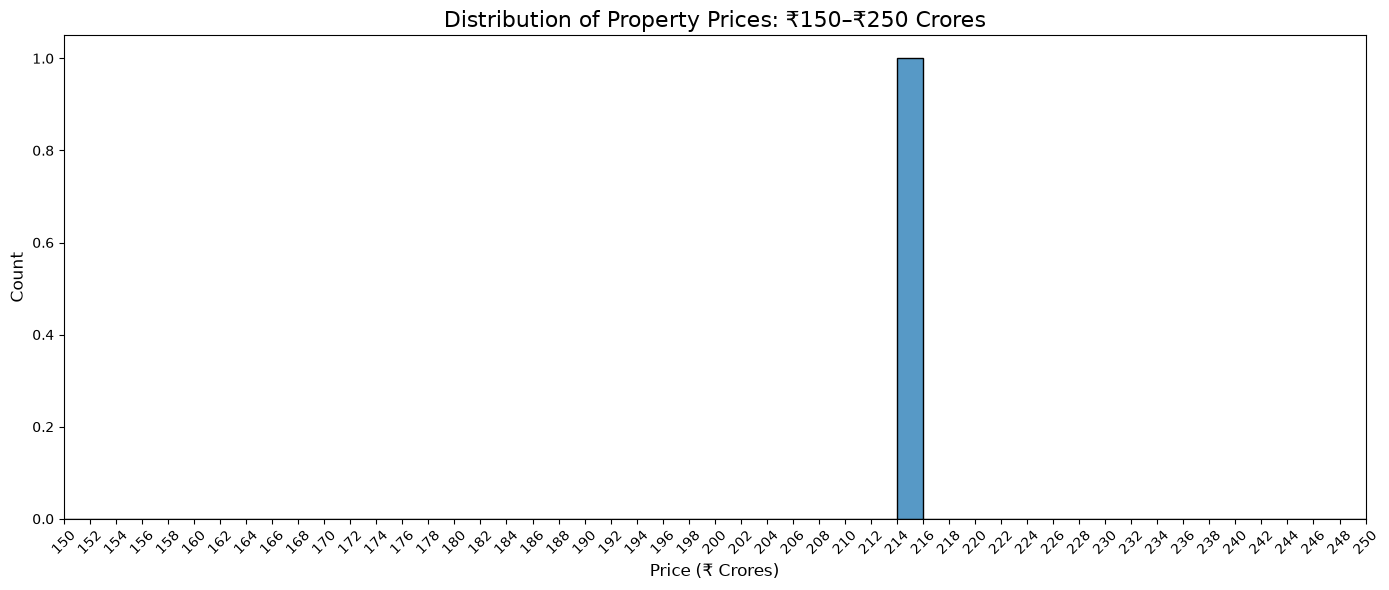

In [ ]:
price_crore = df["price"] / 1e7

# Define ranges
ranges = [
    (0, 50),
    (50, 100),
    (100, 150),
    (150, 250)
]

for start, end in ranges:

    # Select prices within the current range
    data = price_crore[
        (price_crore >= start) & 
        (price_crore < end)
    ]

    plt.figure(figsize=(14, 6))

    sns.histplot(
        data,
        bins=np.arange(start, end + 2, 2),
        edgecolor="black"
    )

    # X-axis every 2 crore
    plt.xticks(
        np.arange(start, end + 1, 2),
        rotation=45
    )

    plt.xlim(start, end)

    plt.title(
        f"Distribution of Property Prices: ₹{start}–₹{end} Crores",
        fontsize=16
    )

    plt.xlabel("Price (₹ Crores)", fontsize=12)
    plt.ylabel("Count", fontsize=12)

    plt.tight_layout()
    plt.show()

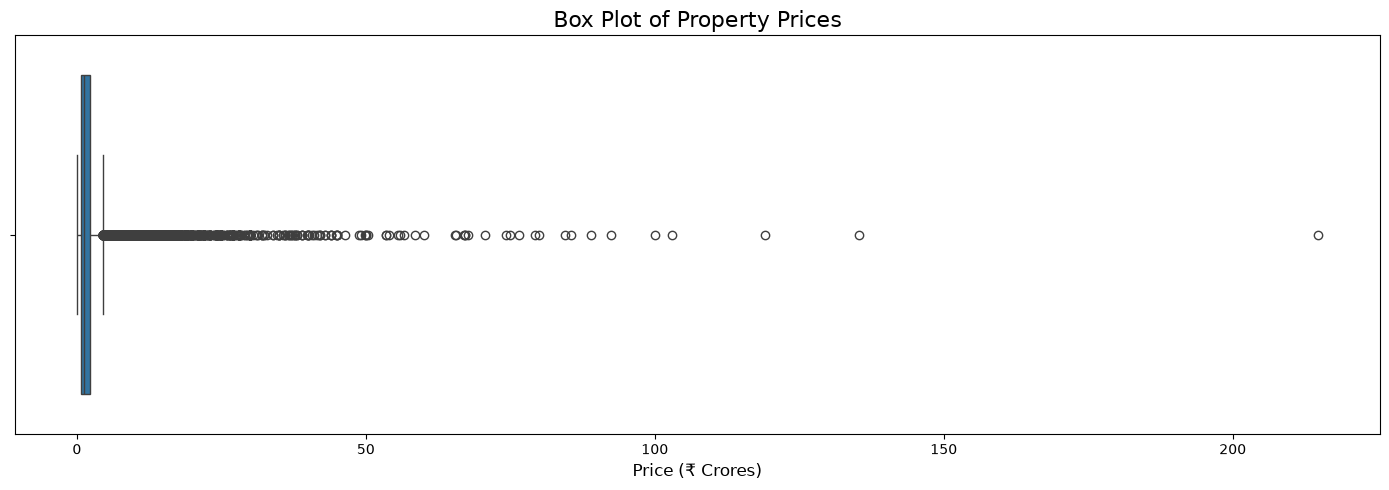

In [ ]:
price_crore = df["price"] / 1e7

plt.figure(figsize=(14, 5))

sns.boxplot(
    x=price_crore
)

plt.title("Box Plot of Property Prices", fontsize=16)
plt.xlabel("Price (₹ Crores)", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 6500000.0
Q3: 22172000.0
IQR: 15672000.0
Lower Bound: -17008000.0
Upper Bound: 45680000.0


In [ ]:
outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Total outliers:", len(outliers))
print("Percentage:", len(outliers) / len(df) * 100)

Total outliers: 4113
Percentage: 8.053178783310164


In [ ]:
outliers[
    ["title", "price", "area", "locality", "bedroom_num", "bathroom_num"]
].sort_values("price", ascending=False).head(100)

,title,price,area,locality,bedroom_num,bathroom_num
35721,Kalpataru Prive,2147483647,24109,Malabar Hill,4,4
35720,Kalpataru Prive,1353723136,10715,Malabar Hill,4,4
50051,Birla Niyaara,1191400000,11914,Worli,7,7
50050,Birla Niyaara,1029567035,10295,Worli,6,6
32956,,999999999,20000,Cuffe Parade,15,15
...,...,...,...,...,...,...
15020,,300000000,8500,Khar,7,7
23021,Ahuja Pali Hill,300000000,5911,Bandra,5,5
7288,,300000000,2500,Malabar Hill,3,3
35981,Indiabulls Sky Forest,300000000,9000,Lower Parel,5,6


In [285]:
df["price_per_sqft"] = df["price"] / df["area"]

df[
    ["title", "price", "area", "price_per_sqft", "locality"]
].sort_values(
    "price_per_sqft",
    ascending=False
).head()

,title,price,area,price_per_sqft,locality
51064,73 East,706730000,2437,290000.000000,Kandivali
30049,Chandak 34 Park Estate,142240000,780,182358.974359,Goregaon
21309,B kumar and brothers the passion group,749181884,4562,164222.245506,Marine Drive
5040,Rustomjee Parishram,415800000,2725,152587.155963,Bandra
51015,Birla Anayu,600000000,4000,150000.000000,Malabar Hill


In [ ]:
# Keep 0-bedroom Studio Apartments; values above 6 are rare and implausible for this dataset.
before_bedroom_filter = len(df)
df = df[df["bedroom_num"] <= 6].reset_index(drop=True)
print(f"Removed {before_bedroom_filter - len(df):,} listings with more than 6 bedrooms.")
display(df[["property_type", "bedroom_num"]].value_counts().sort_index())

Removed 67 listings with more than 6 bedrooms.


property_type      bedroom_num
Apartment          1              16541
                   2              21174
                   3               9898
                   4               2136
                   5                365
                   6                101
Independent Floor  1                 49
                   2                 33
                   3                 15
                   4                 25
                   5                  5
                   6                  4
Independent House  1                 69
                   2                 92
                   3                 97
                   4                 57
                   5                 16
                   6                  8
Studio Apartment   0                  2
Villa              1                 21
                   2                 76
                   3                129
                   4                 55
                   5                 30
         

The price column contains no missing, zero, or negative values. However, its distribution is highly right-skewed, with most properties concentrated in the lower price range and a small number of very high-priced properties. Box-plot analysis identifies many statistical outliers, but further analysis of price_per_sqft, area, title, and locality shows that several high-priced properties are associated with premium locations and may be genuine luxury properties. Therefore, the outliers should not be removed solely based on the IQR method; suspicious values should be investigated individually.

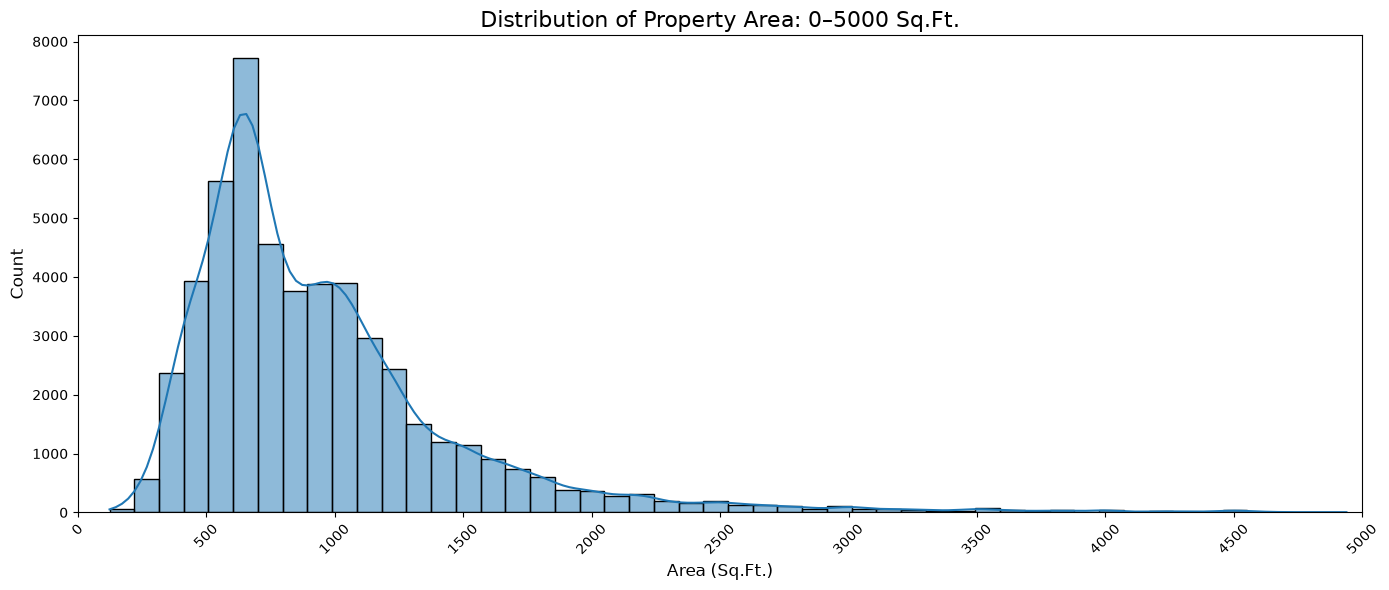

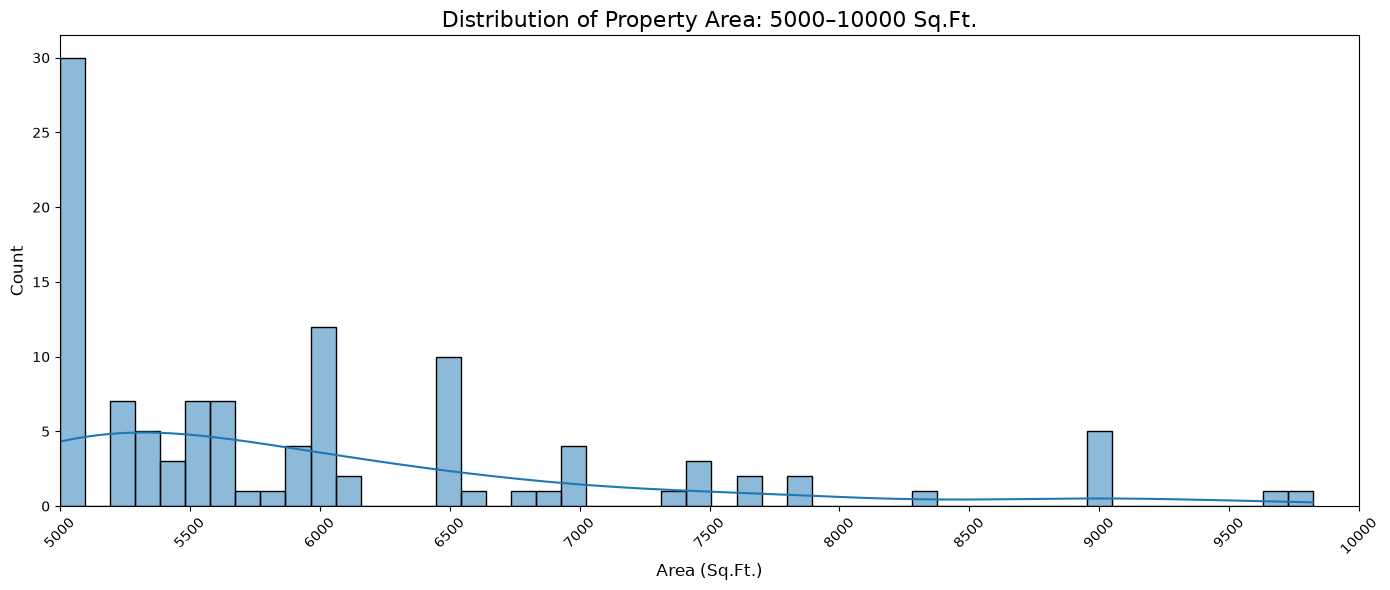

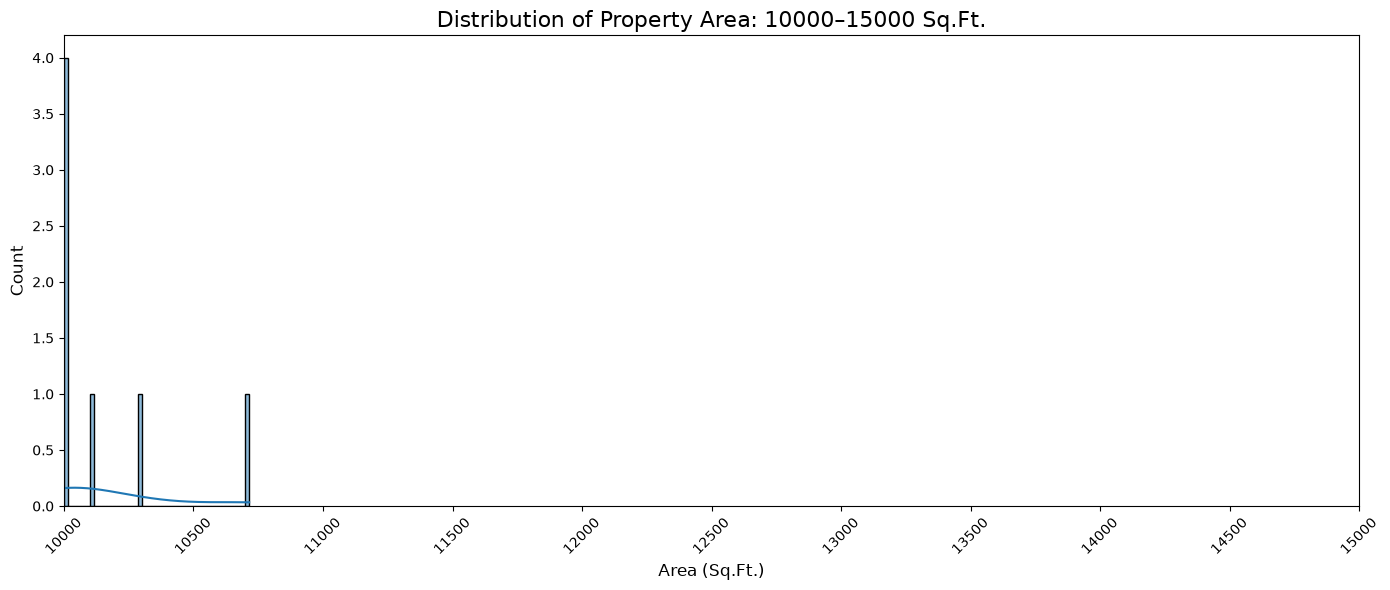

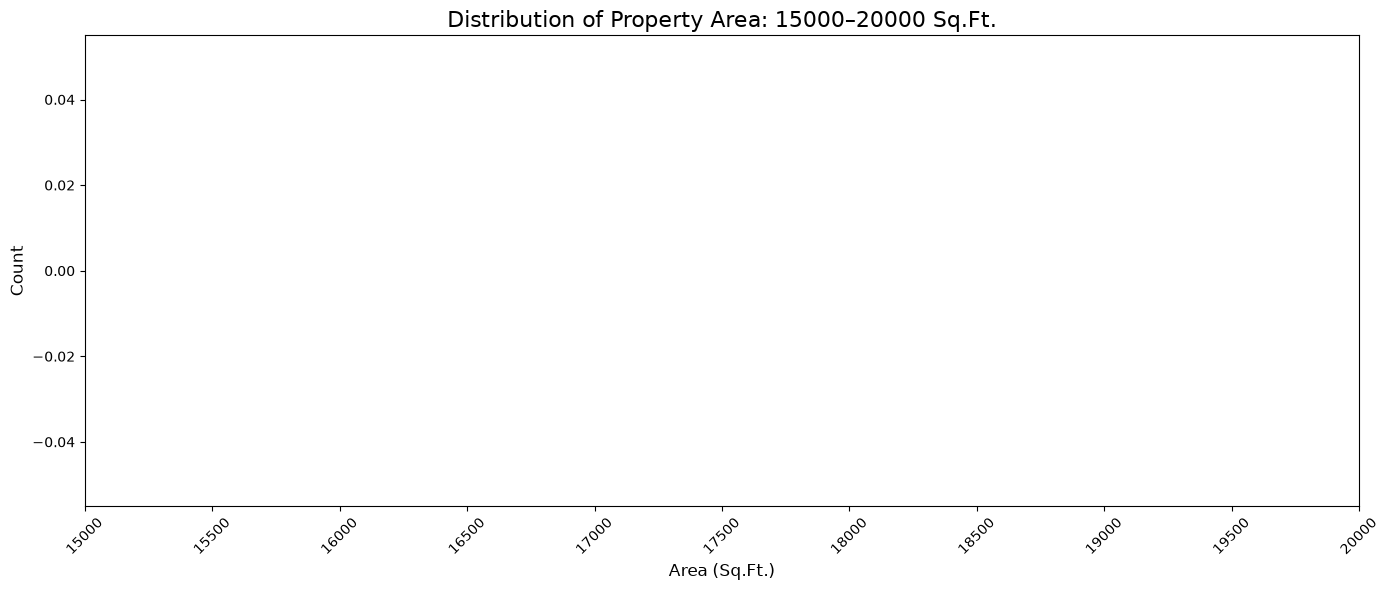

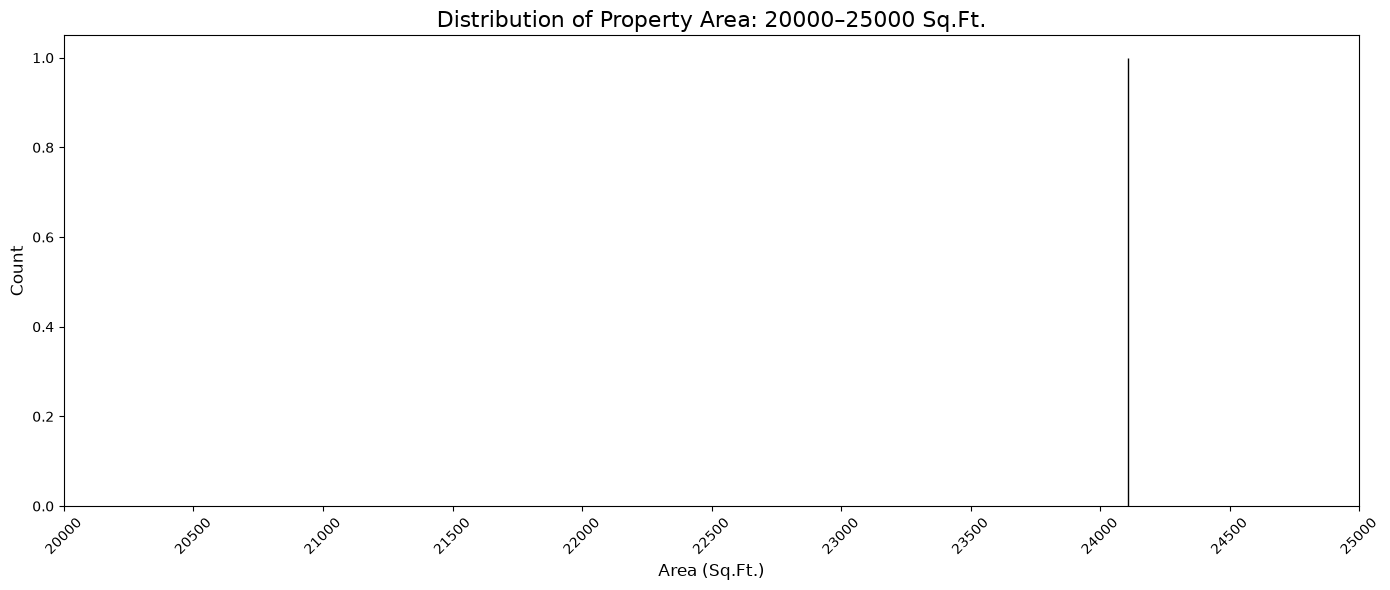

In [ ]:
df["area"] = pd.to_numeric(df["area"], errors="coerce")

area = df["area"].dropna()

ranges = [
    (0, 5000),
    (5000, 10000),
    (10000, 15000),
    (15000, 20000),
    (20000, 25000)
]

for start, end in ranges:

    data = area[
        (area >= start) &
        (area < end)
    ]

    plt.figure(figsize=(14, 6))

    sns.histplot(
        data,
        bins=50,
        kde=True,
        edgecolor="black"
    )

    plt.xlim(start, end)

    plt.xticks(
        np.arange(start, end + 1, 500),
        rotation=45
    )

    plt.title(
        f"Distribution of Property Area: {start}–{end} Sq.Ft.",
        fontsize=16
    )
    plt.xlabel("Area (Sq.Ft.)", fontsize=12)
    plt.ylabel("Count", fontsize=12)

    plt.tight_layout()
    plt.show()

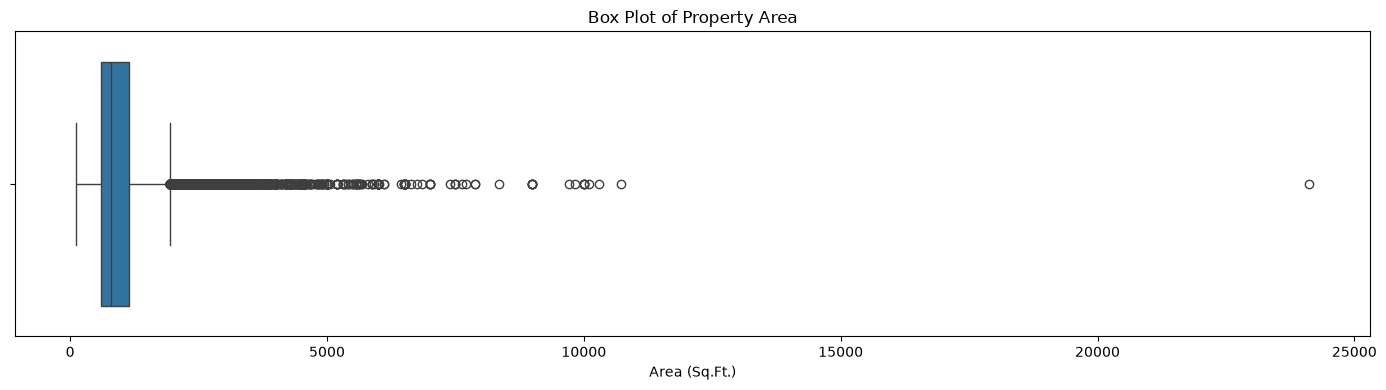

In [ ]:
plt.figure(figsize=(14, 4))

sns.boxplot(x=df["area"])

plt.title("Box Plot of Property Area")
plt.xlabel("Area (Sq.Ft.)")

plt.tight_layout()
plt.show()

In [289]:
area_outliers = df[
    df["area"] > df["area"].quantile(0.95)
]

area_outliers[
    ["title", "area", "price", "price_per_sqft", "locality",
     "property_type", "bedroom_num", "bathroom_num"]
].sort_values("area", ascending=False).head(30)

,title,area,price,price_per_sqft,locality,property_type,bedroom_num,bathroom_num
35661,Kalpataru Prive,24109,2147483647,89073.941142,Malabar Hill,Apartment,4,4
35660,Kalpataru Prive,10715,1353723136,126339.070089,Malabar Hill,Apartment,4,4
49985,Birla Niyaara,10295,1029567035,100006.511413,Worli,Apartment,6,6
50328,SD The Imperial,10105,792548993,78431.369916,Tardeo,Apartment,5,5
30053,,10000,250000000,25000.000000,Lokhandwala Complex,Independent House,6,7
46880,Akshar EL Castillo,10000,360000000,36000.000000,Nerul,Apartment,6,6
35221,,10000,500000000,50000.000000,Juhu Scheme,Apartment,6,6
22981,SD The Imperial Edge,10000,250000000,25000.000000,Tardeo,Apartment,6,6
50106,MICL Aaradhya Onepark,9822,245550000,25000.000000,Ghatkopar,Apartment,6,6
50704,Lokhandwala Minerva,9710,534240413,55019.609990,Mahalaxmi,Apartment,6,6


In [ ]:
df[
    ["title", "area", "price", "price_per_sqft", "locality",
     "bedroom_num", "bathroom_num"]
].sort_values("area", ascending=False).head(30)

,title,area,price,price_per_sqft,locality,bedroom_num,bathroom_num
35661,Kalpataru Prive,24109,2147483647,89073.941142,Malabar Hill,4,4
35660,Kalpataru Prive,10715,1353723136,126339.070089,Malabar Hill,4,4
49985,Birla Niyaara,10295,1029567035,100006.511413,Worli,6,6
50328,SD The Imperial,10105,792548993,78431.369916,Tardeo,5,5
35221,,10000,500000000,50000.000000,Juhu Scheme,6,6
30053,,10000,250000000,25000.000000,Lokhandwala Complex,6,7
22981,SD The Imperial Edge,10000,250000000,25000.000000,Tardeo,6,6
46880,Akshar EL Castillo,10000,360000000,36000.000000,Nerul,6,6
50106,MICL Aaradhya Onepark,9822,245550000,25000.000000,Ghatkopar,6,6
50704,Lokhandwala Minerva,9710,534240413,55019.609990,Mahalaxmi,6,6


The area column contains several statistical outliers, including very large properties above 5,000 sq.ft. However, many of these observations are associated with high-value properties, premium locations, and luxury projects, indicating that they may represent genuine large residential properties rather than data errors. Therefore, area outliers should be investigated rather than removed blindly.

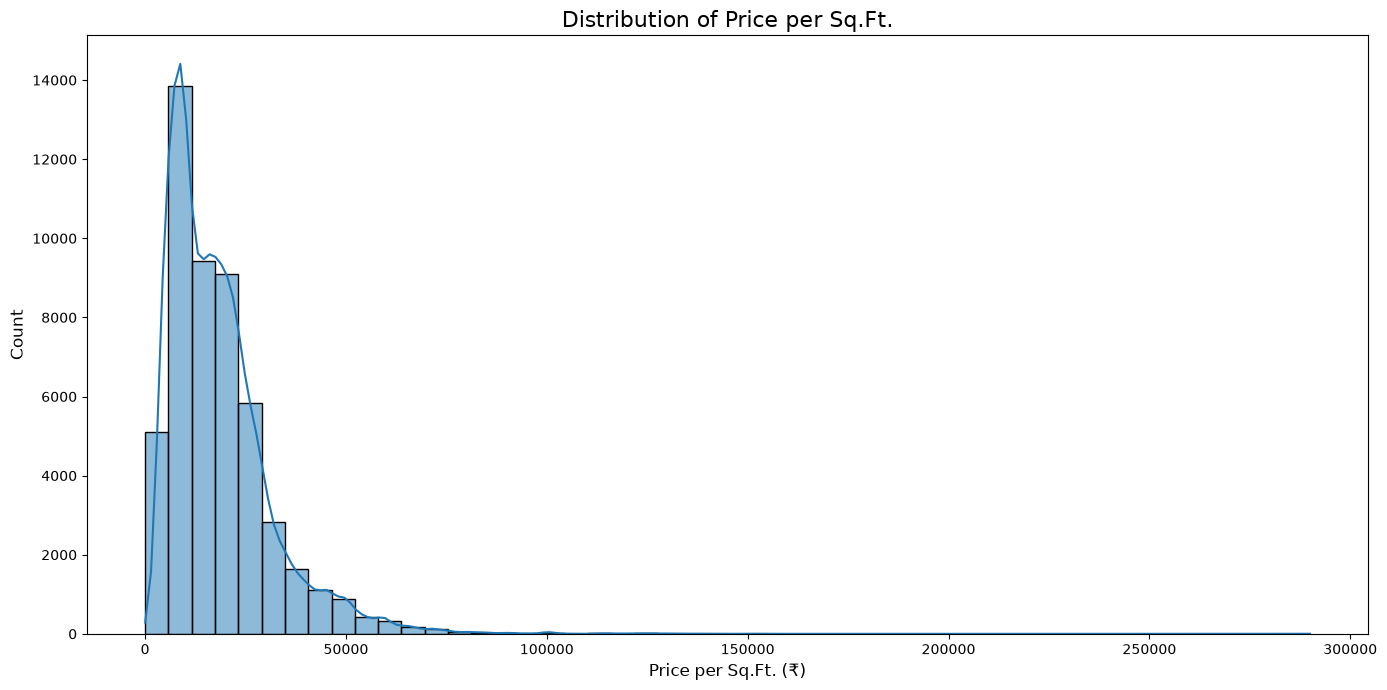

In [ ]:
df["price_per_sqft"] = pd.to_numeric(
    df["price_per_sqft"],
    errors="coerce"
)

df = df.dropna(subset=["price_per_sqft"])

plt.figure(figsize=(14, 7))

sns.histplot(
    df["price_per_sqft"],
    bins=50,
    kde=True,
    edgecolor="black"
)

plt.title("Distribution of Price per Sq.Ft.", fontsize=16)
plt.xlabel("Price per Sq.Ft. (₹)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

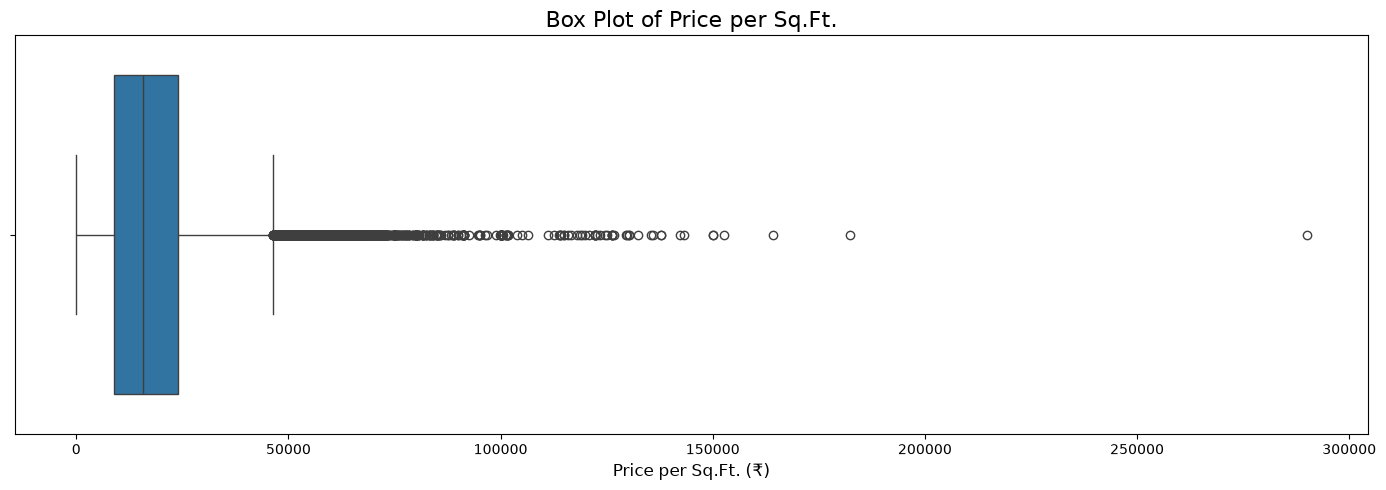

In [ ]:
plt.figure(figsize=(14, 5))

sns.boxplot(
    x=df["price_per_sqft"]
)

plt.title("Box Plot of Price per Sq.Ft.", fontsize=16)
plt.xlabel("Price per Sq.Ft. (₹)", fontsize=12)

plt.tight_layout()
plt.show()

- price_per_sqft:
The distribution is highly right-skewed with a long right tail.
The box plot shows many statistical outliers, including some very high price-per-sq.ft. values.
These outliers should not be removed automatically because premium properties and locations can legitimately have much higher prices per sq.ft.
Suspicious extreme values should be checked using price, area, locality, and property details.

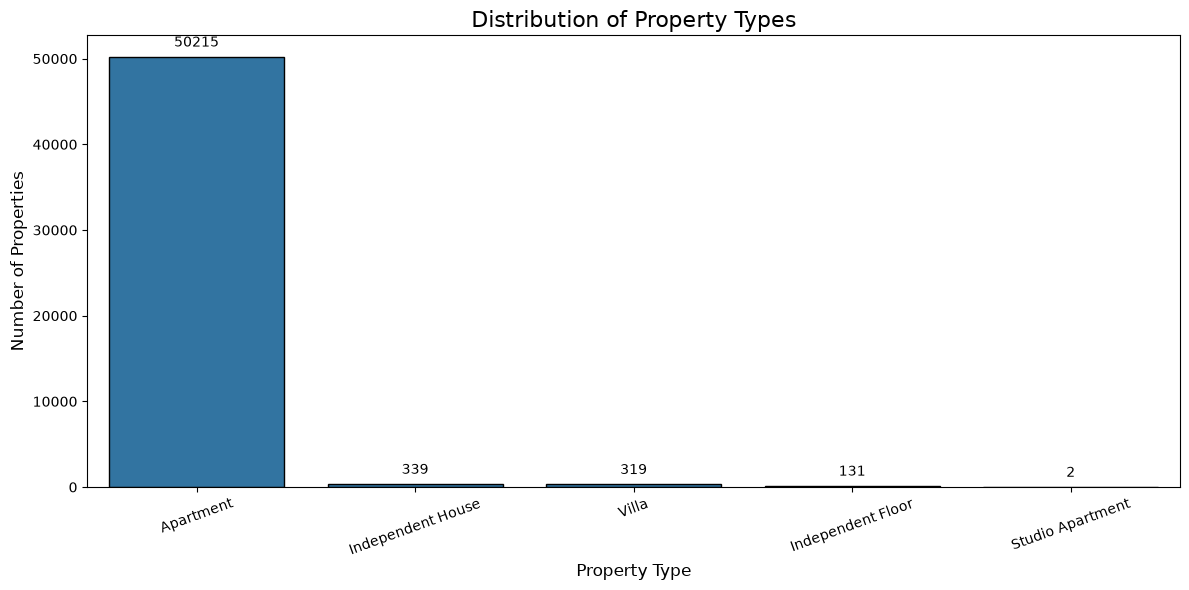

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df,
    x="property_type",
    order=df["property_type"].value_counts().index,
    edgecolor="black"
)

plt.title("Distribution of Property Types", fontsize=16)
plt.xlabel("Property Type", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontsize=10)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

- property_type:
Apartment is the dominant property type. Use the count plot above after running the notebook from top to bottom for the current counts, because the cleaning filters change the dataset size.

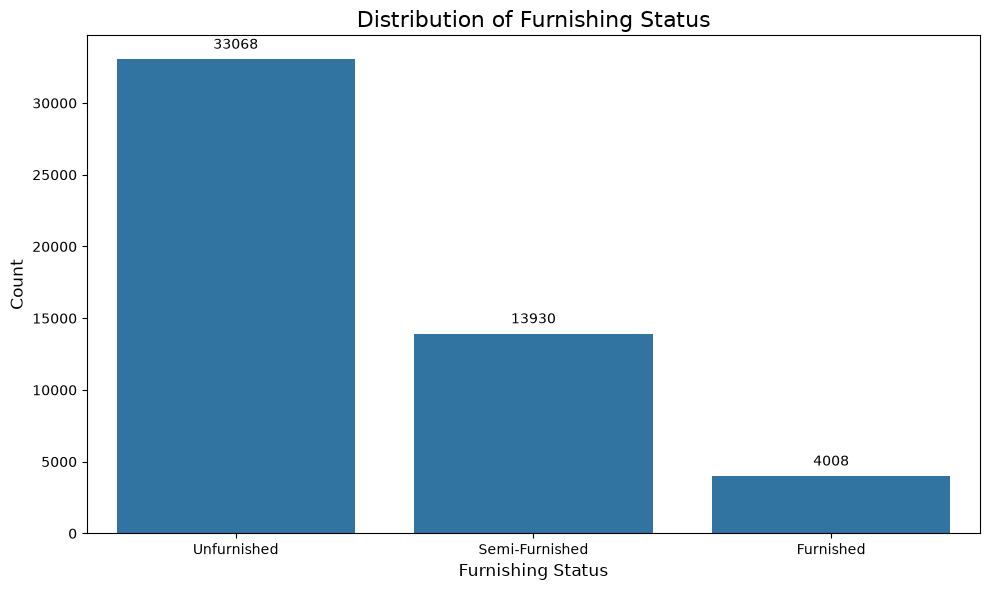

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="furnished",
    order=df["furnished"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=5)

plt.title("Distribution of Furnishing Status", fontsize=16)
plt.xlabel("Furnishing Status", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

- furnished:
Unfurnished is the most frequent category, followed by Semi-Furnished and Furnished. The exact counts should be read from the current plot after all cleaning steps run.

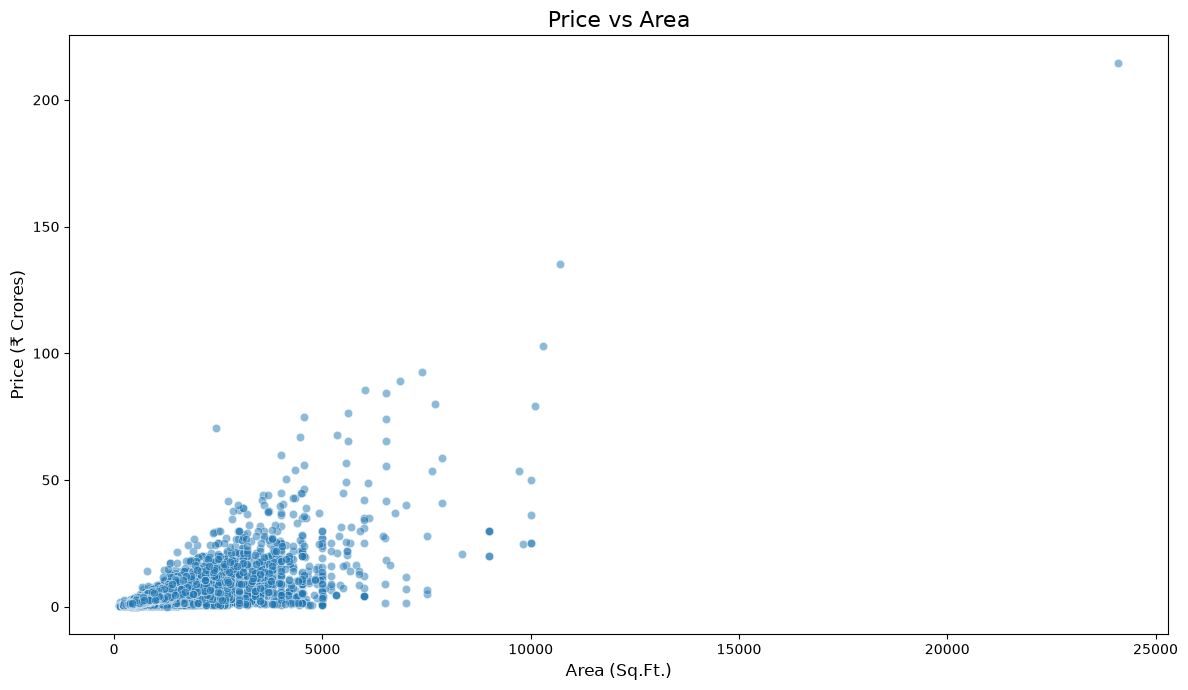

In [ ]:
price_crore = df["price"] / 1e7

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x=df["area"],
    y=price_crore,
    alpha=0.5
)

plt.title("Price vs Area", fontsize=16)
plt.xlabel("Area (Sq.Ft.)", fontsize=12)
plt.ylabel("Price (₹ Crores)", fontsize=12)

plt.tight_layout()
plt.show()

- Price vs Area:
The scatter plot shows a positive relationship between property area and price, as larger properties generally have higher prices. However, the relationship is not perfectly linear, indicating that other factors such as location, property type, BHK, and furnishing also influence price. A few extreme observations are visible and should be investigated rather than removed blindly.

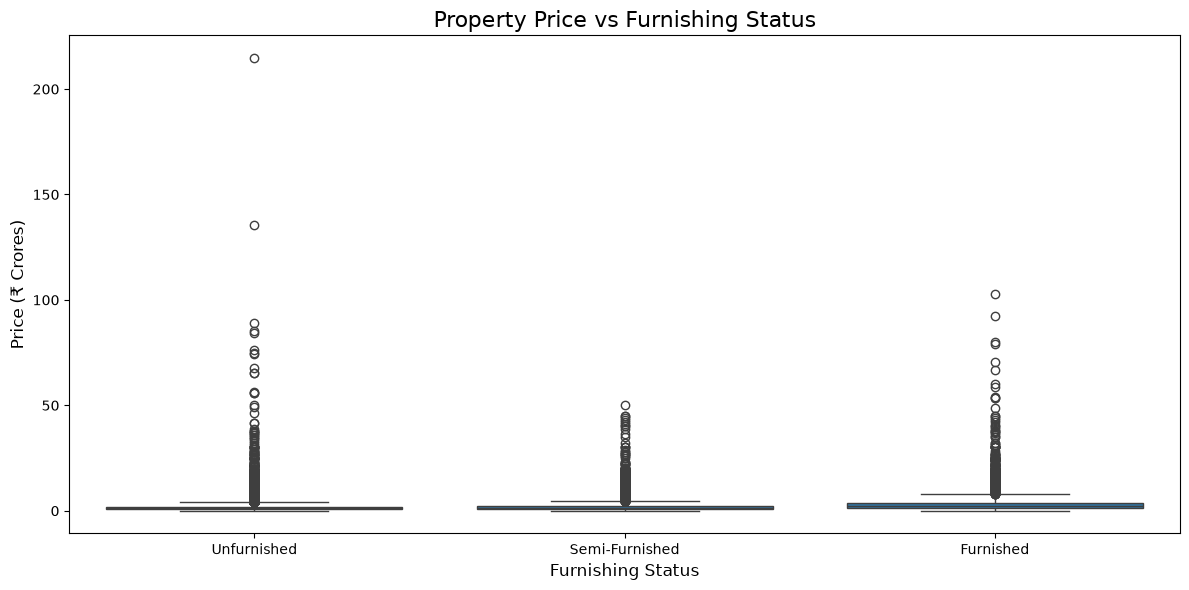

In [ ]:
price_crore = df["price"] / 1e7

plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["furnished"],
    y=price_crore
)

plt.title("Property Price vs Furnishing Status", fontsize=16)
plt.xlabel("Furnishing Status", fontsize=12)
plt.ylabel("Price (₹ Crores)", fontsize=12)

plt.tight_layout()
plt.show()

- Price vs Furnishing Status:
The box plot shows that furnished properties generally have a higher median price than semi-furnished and unfurnished properties. However, there is substantial overlap between the categories and many high-price outliers, indicating that factors such as location, area, and property type also strongly influence property prices.

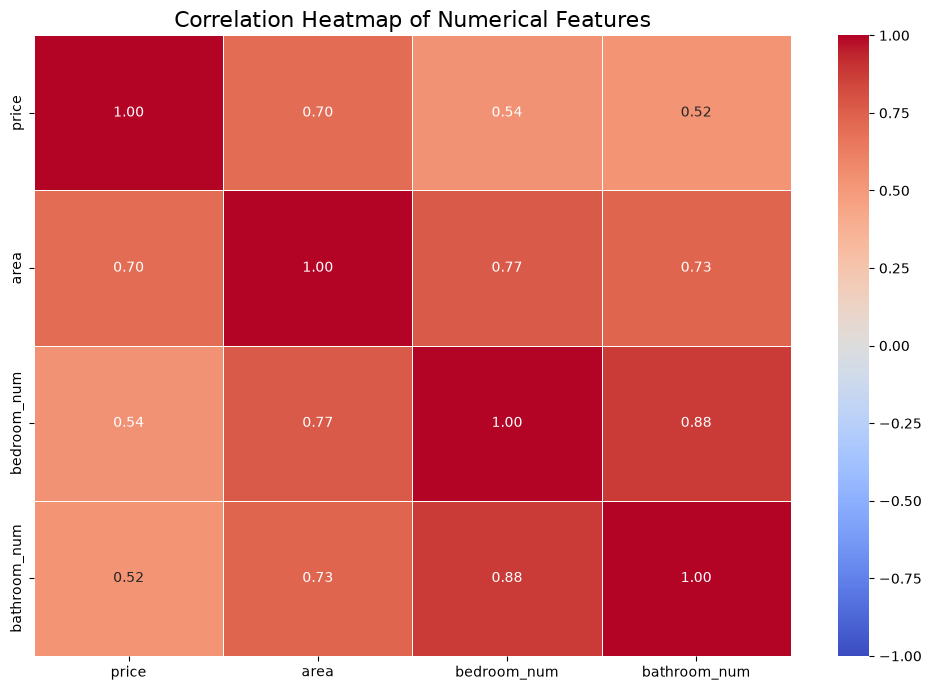

In [ ]:
numeric_cols = [
    "price",
    "area",
    "bedroom_num",
    "bathroom_num"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

- Correlation Heatmap:
Price has a strong positive correlation with area, while bedroom_num and bathroom_num show moderate positive correlations.
Bedroom_num and bathroom_num have a very strong correlation, while area is also strongly correlated with bedroom_num and bathroom_num.
Note: age is not included in this heatmap because it was dropped during cleaning.

## Final data-quality validation

This check is deliberately conservative: it corrects derived values and flags invalid records, without deleting legitimate luxury properties solely because they are statistical outliers.

In [298]:
# Recalculate the derived feature from the two source columns.
# This is safer than trusting a scraped/calculated price_per_sqft field.
df["price_per_sqft"] = df["price"] / df["area"]

quality_report = pd.DataFrame({
    "check": [
        "Rows after cleaning",
        "Exact duplicate rows",
        "Rows with missing required values",
        "Rows with non-positive price or area",
        "Rows with bedroom_num > 6",
    ],
    "count": [
        len(df),
        df.duplicated().sum(),
        df[["price", "area", "locality", "property_type", "bedroom_num", "bathroom_num"]].isna().any(axis=1).sum(),
        ((df["price"] <= 0) | (df["area"] <= 0)).sum(),
        (df["bedroom_num"] > 6).sum(),
    ],
})
display(quality_report)

# Do not automatically remove IQR outliers: inspect them using price per sq.ft. and locality.
suspicious_listings = df.loc[
    (df["price_per_sqft"] < df["price_per_sqft"].quantile(0.01))
    | (df["price_per_sqft"] > df["price_per_sqft"].quantile(0.99)),
    ["title", "locality", "price", "area", "price_per_sqft", "bedroom_num"],
].sort_values("price_per_sqft", ascending=False)
display(suspicious_listings.head(20))

,check,count
0,Rows after cleaning,51006
1,Exact duplicate rows,0
2,Rows with missing required values,0
3,Rows with non-positive price or area,0
4,Rows with bedroom_num > 6,0


,title,locality,price,area,price_per_sqft,bedroom_num
50997,73 East,Kandivali,706730000,2437,290000.000000,4
29996,Chandak 34 Park Estate,Goregaon,142240000,780,182358.974359,2
21286,B kumar and brothers the passion group,Marine Drive,749181884,4562,164222.245506,4
5034,Rustomjee Parishram,Bandra,415800000,2725,152587.155963,4
50284,Nishika Elysium,Worli,669000000,4460,150000.000000,5
50948,Birla Anayu,Malabar Hill,600000000,4000,150000.000000,4
29672,Raheja Willows,Kandivali,215000880,1500,143333.920000,3
23685,B kumar and brothers the passion group,Colaba,854616165,6011,142175.372650,4
50549,Shapoorji Pallonji The Odyssey 1,Girgaon,244892332,1777,137812.229600,3
50550,Shapoorji Pallonji The Odyssey 1,Girgaon,265425912,1926,137812.000000,4


,listings,median_price_cr,median_price_per_sqft,median_area_sqft
locality,,,,
Tardeo,76,9.00,57473.39,1450.0
Mahalaxmi,162,7.50,50550.14,1590.0
Juhu,166,9.00,48449.52,1810.5
Prabhadevi,208,6.50,47767.86,1338.5
Khar,131,6.00,47619.05,1300.0
Lower Parel,348,6.68,46877.52,1363.0
Worli,184,8.00,46332.74,1784.0
Vile Parle,124,7.50,45258.14,1490.0
Matunga,259,4.10,45003.08,1059.0


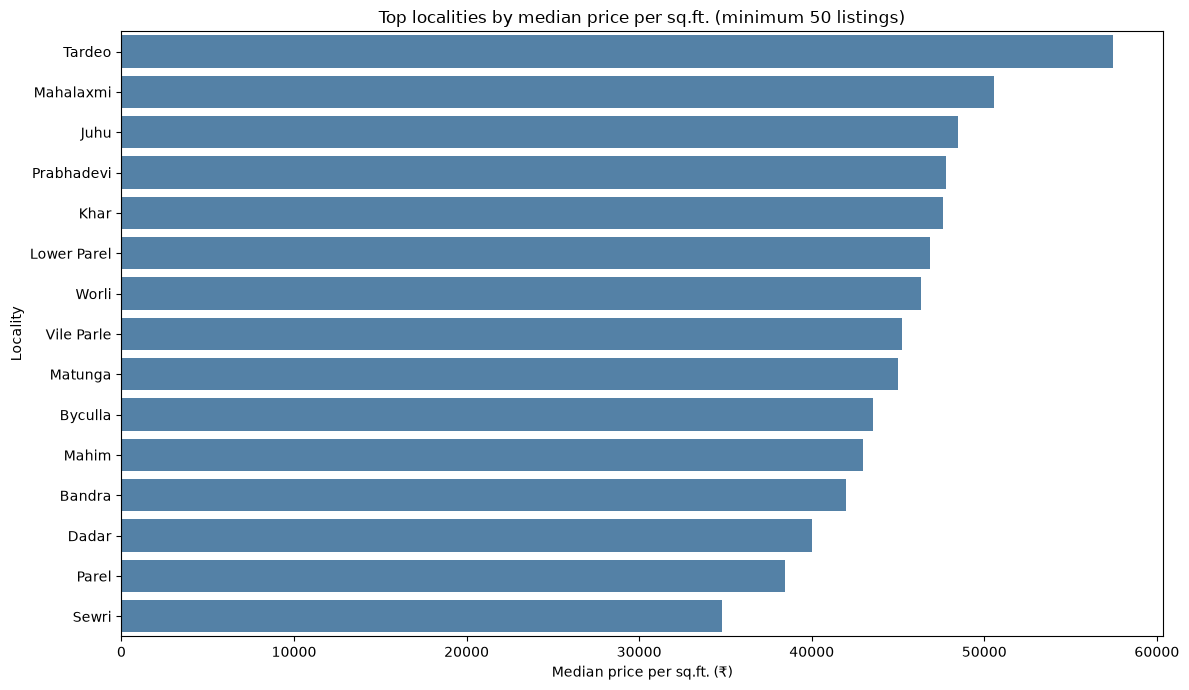

In [299]:
# Compare localities only when enough listings are available; medians are robust to luxury-property outliers.
locality_summary = (
    df.groupby("locality")
      .agg(listings=("price", "size"),
           median_price_cr=("price", lambda s: s.median() / 1e7),
           median_price_per_sqft=("price_per_sqft", "median"),
           median_area_sqft=("area", "median"))
      .query("listings >= 50")
      .sort_values("median_price_per_sqft", ascending=False)
)
display(locality_summary.head(15).round(2))

plt.figure(figsize=(12, 7))
sns.barplot(data=locality_summary.head(15).reset_index(), x="median_price_per_sqft", y="locality", color="steelblue")
plt.title("Top localities by median price per sq.ft. (minimum 50 listings)")
plt.xlabel("Median price per sq.ft. (₹)")
plt.ylabel("Locality")
plt.tight_layout()
plt.show()